# Future Sales Prediction

Importing the libraries for sales forecasting and model evaluation.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

Loads the already cleaned dataset.

In [5]:
df = pd.read_csv("Supermart_Grocery_Cleaned.csv")

Converts Order Date into datetime format because CSV files load dates as text.

In [6]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

Creates monthly total sales for time-series forecasting.

In [7]:
monthly_sales = df.set_index("Order Date").resample("MS")["Sales"].sum()

Displays the monthly sales data used by the forecasting model.

In [8]:
monthly_sales

,Sales
Order Date,
2015-01-01,122497
2015-02-01,66030
2015-03-01,247156
2015-04-01,203258
2015-05-01,164263
2015-06-01,206064
2015-07-01,220986
2015-08-01,230161
2015-09-01,382200


Uses the last 12 months as test data and the earlier months as training data.

In [9]:
train = monthly_sales.iloc[:-12]
test = monthly_sales.iloc[-12:]

Creates a Holt-Winters forecasting model with trend and yearly seasonality.

In [10]:
model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

Trains the forecasting model using the training data.

In [11]:
model_fit = model.fit()

Predicts sales for the 12-month test period.

In [12]:
predictions = model_fit.forecast(12)

Calculates Mean Absolute Error to measure the average prediction error.

In [13]:
mae = mean_absolute_error(test, predictions)
print("MAE:", round(mae, 2))

MAE: 44972.95


Calculates Root Mean Squared Error to give more weight to larger prediction errors.

In [14]:
rmse = mean_squared_error(test, predictions) ** 0.5
print("RMSE:", round(rmse, 2))

RMSE: 58276.6


Calculates Mean Absolute Percentage Error to measure prediction error as a percentage.

In [15]:
mape = np.mean(np.abs((test.values - predictions.values) / test.values)) * 100
print("MAPE:", round(mape, 2), "%")

MAPE: 10.8 %


Creates a table to compare actual and predicted sales.

In [16]:
comparison = pd.DataFrame({
    "Actual Sales": test.values,
    "Predicted Sales": predictions.values
}, index=test.index)

comparison

,Actual Sales,Predicted Sales
Order Date,,
2018-01-01,234739,199700.382494
2018-02-01,166267,203207.518754
2018-03-01,355704,320768.562395
2018-04-01,310150,337528.029965
2018-05-01,367411,373810.625020
2018-06-01,354902,348773.905238
2018-07-01,337092,360326.054336
2018-08-01,331014,374232.772199
2018-09-01,705680,557943.554255


Compares actual sales with predicted sales visually.

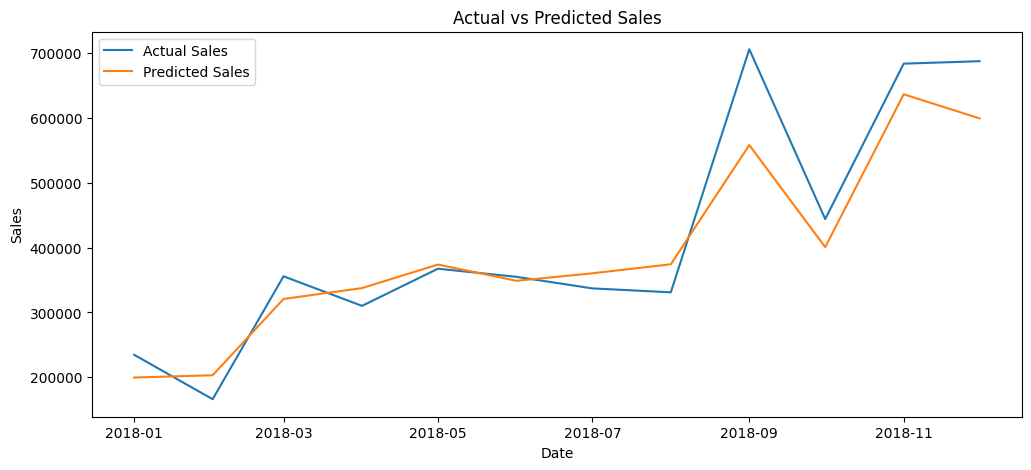

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(test.index, test.values, label="Actual Sales")
plt.plot(predictions.index, predictions.values, label="Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

Creates the final forecasting model using all available monthly sales data.

In [18]:
final_model = ExponentialSmoothing(
    monthly_sales,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

Trains the final model using the complete monthly sales history.

In [19]:
final_model_fit = final_model.fit()

In [23]:
final_model_fit.save("holt_winters_sales_model.pkl")

Forecasts sales for the next six months.

In [20]:
future_sales = final_model_fit.forecast(6)

Displays the predicted sales for the next six months.

In [21]:
future_forecast = pd.DataFrame({
    "Forecasted Sales": future_sales.round(2)
})

future_forecast

,Forecasted Sales
2019-01-01,340619.72
2019-02-01,326120.93
2019-03-01,476022.36
2019-04-01,475799.18
2019-05-01,519586.45
2019-06-01,508138.18


Shows historical monthly sales together with the six-month future forecast.

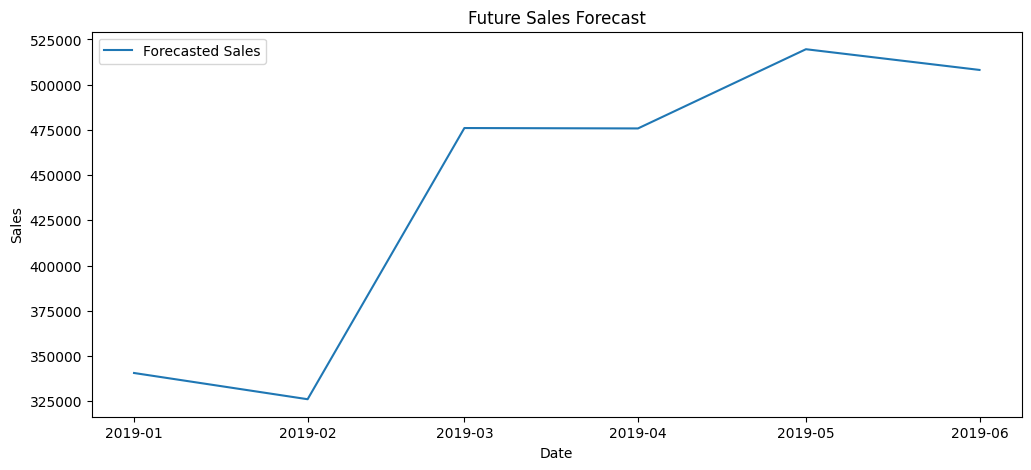

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(future_sales.index, future_sales.values, label="Forecasted Sales")
plt.title("Future Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

**Model Result:** The Holt-Winters model achieved a MAPE of about 10.80% on the 2018 test period. After evaluation, the model was retrained using all available monthly sales data and used to forecast sales for the next six months.